In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

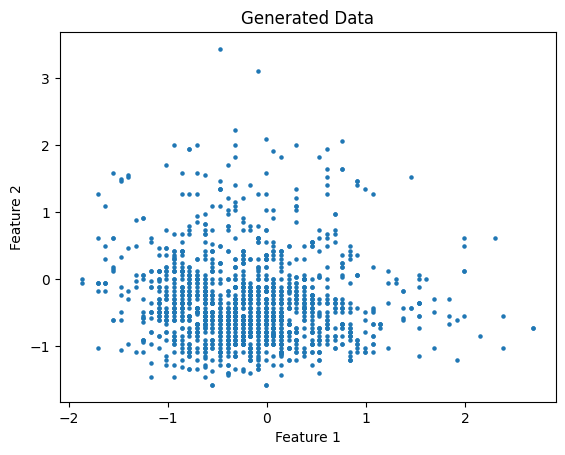

In [ ]:
df = pd.read_csv("winequality-total.csv", sep = ';')

X = df.drop('quality', axis = 1).values
y = df['quality'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X_scaled[:1500, 0], X_scaled[:1500, 1], s=5)
plt.title("Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
def EuclideanDistance(x1, x2):
    ED = np.sqrt(np.sum((x1 - x2)**2))
    return ED

class KMeansNumpy:
  def __init__(self, k = 5, max_iters = 100, random_state = 42):
    self.k = k
    self.max_iters = max_iters
    self.clusters = None
    self.centroids = []
    self.random_state = random_state
    np.random.seed(self.random_state)

  def fit(self, X):
    self.centroids = []
    self.X = X
    self.n_samples, self.n_features = X.shape
    indices = np.random.choice(self.n_samples, self.k, replace = False)
    for index in indices:
      self.centroids.append(X[index])

    for i in range(self.max_iters):
      self.clusters = self.create_clusters(self.centroids)
      centroids_old = self.centroids
      self.centroids = self.get_centroids(self.clusters)
      if self.is_converged(centroids_old, self.centroids):
        break
    return self.get_cluster_labels(self.clusters)

  def get_cluster_labels(self, clusters):
    labels = np.empty(self.n_samples)
    for cluster_index, cluster in enumerate(clusters):
      for row in cluster:
        labels[row] = cluster_index
    return labels


  def create_clusters(self, centroids):
    clusters = []
    for i in range(self.k):
      clusters.append([])
    for index, sample in enumerate(self.X):
      closest_index = self.closest_centroid(sample, centroids)
      clusters[closest_index].append(index)
    return clusters


  def closest_centroid(self, sample, centroids):
    distances = []
    for centroid in centroids:
      distance = EuclideanDistance(sample, centroid)
      distances.append(distance)
    return np.argmin(distances)


  def get_centroids(self, clusters):
    new_centroids = []
    for cluster in clusters:
      new_centroid = np.mean(self.X[cluster], axis = 0)
      new_centroids.append(new_centroid)
    return new_centroids


  def is_converged(self, centroids_old, centroids):
    distance = 0
    tolerance = 0.0001
    for i in range(self.k):
        dist = EuclideanDistance(centroids_old[i], centroids[i])
        distance += dist
    if distance < tolerance:
      return True
    return False

  def predict(self, X):
    pass

[2. 0. 0. ... 1. 1. 0.]
[[-0.34937827 -0.40301559 -0.00543731 -0.43632124 -0.44311526 -0.09101755
   0.03476735 -0.8518815  -0.03960351 -0.28333683  0.56907198]
 [ 0.87962161  1.18122495 -0.32060106 -0.60463784  0.94317457 -0.83613227
  -1.20512717  0.70749864  0.53668592  0.84283306 -0.1287828 ]
 [-0.18411308 -0.35223428  0.27782583  1.20014455 -0.08871314  0.84651602
   0.95672337  0.75789746 -0.38778324 -0.25803256 -0.79499755]]


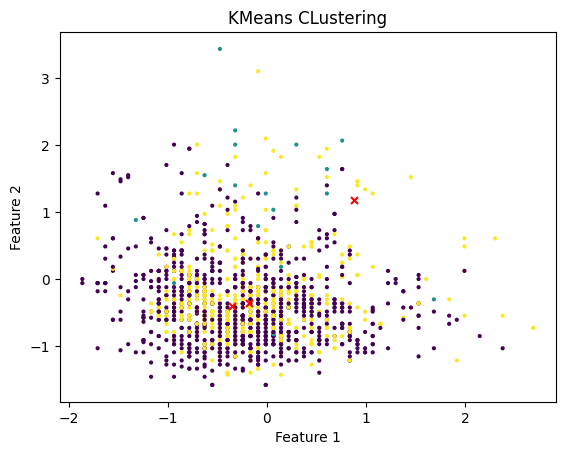

In [ ]:
model = KMeansNumpy(k = 3, random_state = 42)
y_pred = model.fit(X_scaled)
print(y_pred)
print(np.array(model.centroids))

plt.scatter(X_scaled[:1500, 0], X_scaled[:1500, 1], s=4, c=y_pred[:1500], cmap='viridis', label = "Data Points")
centroid_np = np.array(model.centroids)
plt.scatter(centroid_np[:, 0], centroid_np[:, 1], marker='x', s=25, c='red', label = "Centroids")
plt.title("KMeans CLustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# Standardize cluster labels by sorting centroids based on the first feature.
# This makes it easier to visually compare the Numpy implementation against Scikit-Learn.

def sort_clusters(centroids, labels):
    c = np.array(centroids)
    idx = np.argsort(c[:, 0])
    return c[idx], np.argsort(idx)[labels.astype(int)]

sorted_centroids, sorted_labels = sort_clusters(model.centroids, y_pred)

print("Sorted Numpy Centroids:")
print(sorted_centroids)

Sorted Numpy Centroids:
[[-0.34937827 -0.40301559 -0.00543731 -0.43632124 -0.44311526 -0.09101755
   0.03476735 -0.8518815  -0.03960351 -0.28333683  0.56907198]
 [-0.18411308 -0.35223428  0.27782583  1.20014455 -0.08871314  0.84651602
   0.95672337  0.75789746 -0.38778324 -0.25803256 -0.79499755]
 [ 0.87962161  1.18122495 -0.32060106 -0.60463784  0.94317457 -0.83613227
  -1.20512717  0.70749864  0.53668592  0.84283306 -0.1287828 ]]


y_pred: [0 1 1 ... 2 2 1]
centroids: [[-0.18411308 -0.35223428  0.27782583  1.20014455 -0.08871314  0.84651602
   0.95672337  0.75789746 -0.38778324 -0.25803256 -0.79499755]
 [-0.34937827 -0.40301559 -0.00543731 -0.43632124 -0.44311526 -0.09101755
   0.03476735 -0.8518815  -0.03960351 -0.28333683  0.56907198]
 [ 0.87962161  1.18122495 -0.32060106 -0.60463784  0.94317457 -0.83613227
  -1.20512717  0.70749864  0.53668592  0.84283306 -0.1287828 ]]


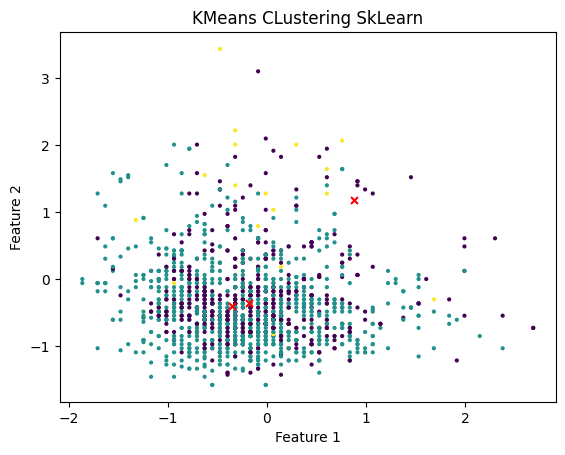

In [ ]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters = 3, random_state=42)
model.fit(X_scaled)
y_predsk = model.predict(X_scaled)
print("y_pred:", y_predsk)
print("centroids:", model.cluster_centers_)

plt.scatter(X_scaled[:1500,0], X_scaled[:1500,1], s = 4, c=y_predsk[:1500], cmap='viridis', label = "Data Points")
centroid_sk = model.cluster_centers_
plt.scatter(centroid_sk[:,0], centroid_sk[:,1], marker='x', s=25, c='red', label = "Centroids")
plt.title("KMeans CLustering SkLearn")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
#Sorting centroids to see if it matches numpy centroids.

print("Sorted Sklearn Centroids (for comparison):")
print(centroid_sk[np.argsort(centroid_sk[:,0])])

Sorted Sklearn Centroids (for comparison):
[[-0.34937827 -0.40301559 -0.00543731 -0.43632124 -0.44311526 -0.09101755
   0.03476735 -0.8518815  -0.03960351 -0.28333683  0.56907198]
 [-0.18411308 -0.35223428  0.27782583  1.20014455 -0.08871314  0.84651602
   0.95672337  0.75789746 -0.38778324 -0.25803256 -0.79499755]
 [ 0.87962161  1.18122495 -0.32060106 -0.60463784  0.94317457 -0.83613227
  -1.20512717  0.70749864  0.53668592  0.84283306 -0.1287828 ]]
